# Experiment - ResNet18 fine-tuning on whole slides (discarded)

Progressive unfreezing of a ResNet18 backbone on mask-cropped whole slides, with a check on which parameters are actually trainable at each stage.

Discarded: same ceiling as every other whole-slide approach.

---


## **Google Drive Connection**

In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain train_data/, test_data/ and train_labels.csv
# (see data/README.md).
import os

DATA_DIR = os.environ.get("WSI_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## **Libraries Import**

In [6]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torchview import draw_graph

logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


## **Data Loading**

In [7]:
# Paths to data folders and labels file in Drive
TRAIN_IMG_DIR = 'Dataset/train_img_data'
TRAIN_MASK_DIR = 'Dataset/train_mask_data'
TEST_DATA_DIR = 'Dataset/test_data'
TRAIN_LABELS_PATH = 'Dataset/train_labels.csv'

# Verify paths exist
print("="*70)
print("CHECKING DATA PATHS")
print("="*70)

if os.path.exists(TRAIN_IMG_DIR):
    train_img_files = [f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.png')]
    print(f"Train images folder found")
    print(f"Path: {TRAIN_IMG_DIR}")
    print(f"Total files: {len(train_img_files)}")
else:
    print(f"Train images folder NOT found at: {TRAIN_IMG_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TRAIN_MASK_DIR):
    train_mask_files = [f for f in os.listdir(TRAIN_MASK_DIR) if f.endswith('.png')]
    print(f"\n Train masks folder found")
    print(f"Path: {TRAIN_MASK_DIR}")
    print(f"Total files: {len(train_mask_files)}")
else:
    print(f"\n Train masks folder NOT found at: {TRAIN_MASK_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TEST_DATA_DIR):
    test_files = [f for f in os.listdir(TEST_DATA_DIR) if f.endswith('.png')]
    print(f"\n Test data folder found")
    print(f"Path: {TEST_DATA_DIR}")
    print(f"Total files: {len(test_files)}")
else:
    print(f"\n Test data folder NOT found at: {TEST_DATA_DIR}")
    print(f"Please check your Google Drive path!")

if os.path.exists(TRAIN_LABELS_PATH):
    print(f"\n Labels file found")
    print(f"Path: {TRAIN_LABELS_PATH}")
else:
    print(f"\n Labels file NOT found at: {TRAIN_LABELS_PATH}")
    print(f"Please check your Google Drive path!")

print("\n" + "="*70)
print("PATH VERIFICATION COMPLETED")
print("="*70)

CHECKING DATA PATHS
 Train images folder found
  Path: Dataset/train_img_data
  Total files: 580

 Train masks folder found
  Path: Dataset/train_mask_data
  Total files: 580

 Test data folder found
  Path: Dataset/test_data
  Total files: 954

 Labels file found
  Path: Dataset/train_labels.csv

PATH VERIFICATION COMPLETED


## **Exploration and Data Analysis**

Train dataset size: 580

First rows of the dataset:
   sample_index            label
0  img_0000.png  Triple negative
1  img_0002.png        Luminal B
2  img_0003.png        Luminal B
3  img_0004.png        Luminal B
4  img_0006.png        Luminal A

CLASS DISTRIBUTION
label
Luminal B          204
Luminal A          157
HER2(+)            150
Triple negative     69
Name: count, dtype: int64


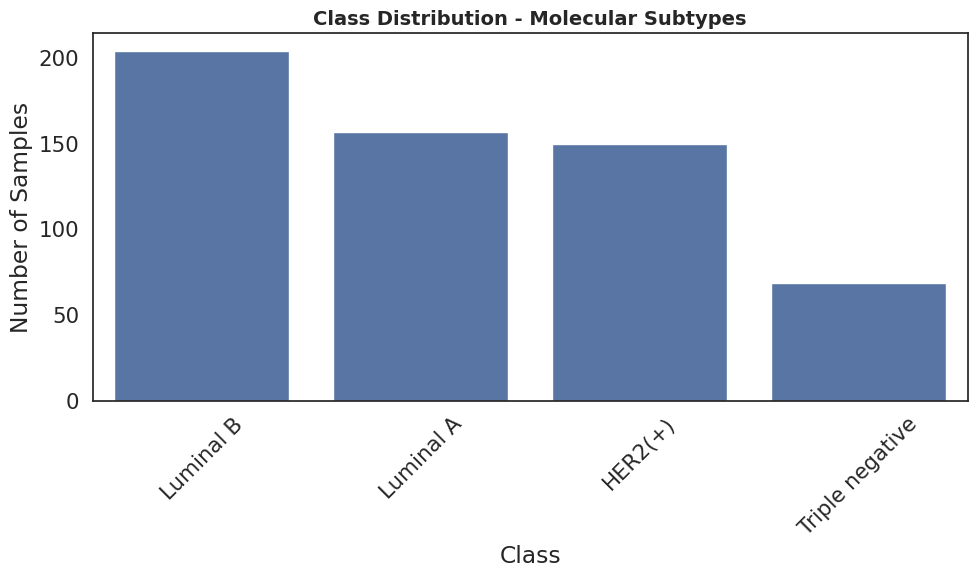


Number of classes: 4


In [8]:
# Load labels
train_labels = pd.read_csv(TRAIN_LABELS_PATH)
print(f"Train dataset size: {len(train_labels)}")
print("\nFirst rows of the dataset:")
print(train_labels.head())

# Class distribution analysis
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
class_counts = train_labels['label'].value_counts()
print(class_counts)

# Visualize distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution - Molecular Subtypes', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Class to index mapping
label_to_idx = {
    'Luminal A': 0,
    'Luminal B': 1,
    'HER2(+)': 2,
    'Triple negative': 3
}
idx_to_label = {v: k for k, v in label_to_idx.items()}

print(f"\nNumber of classes: {len(label_to_idx)}")


Visualizing sample images and masks...


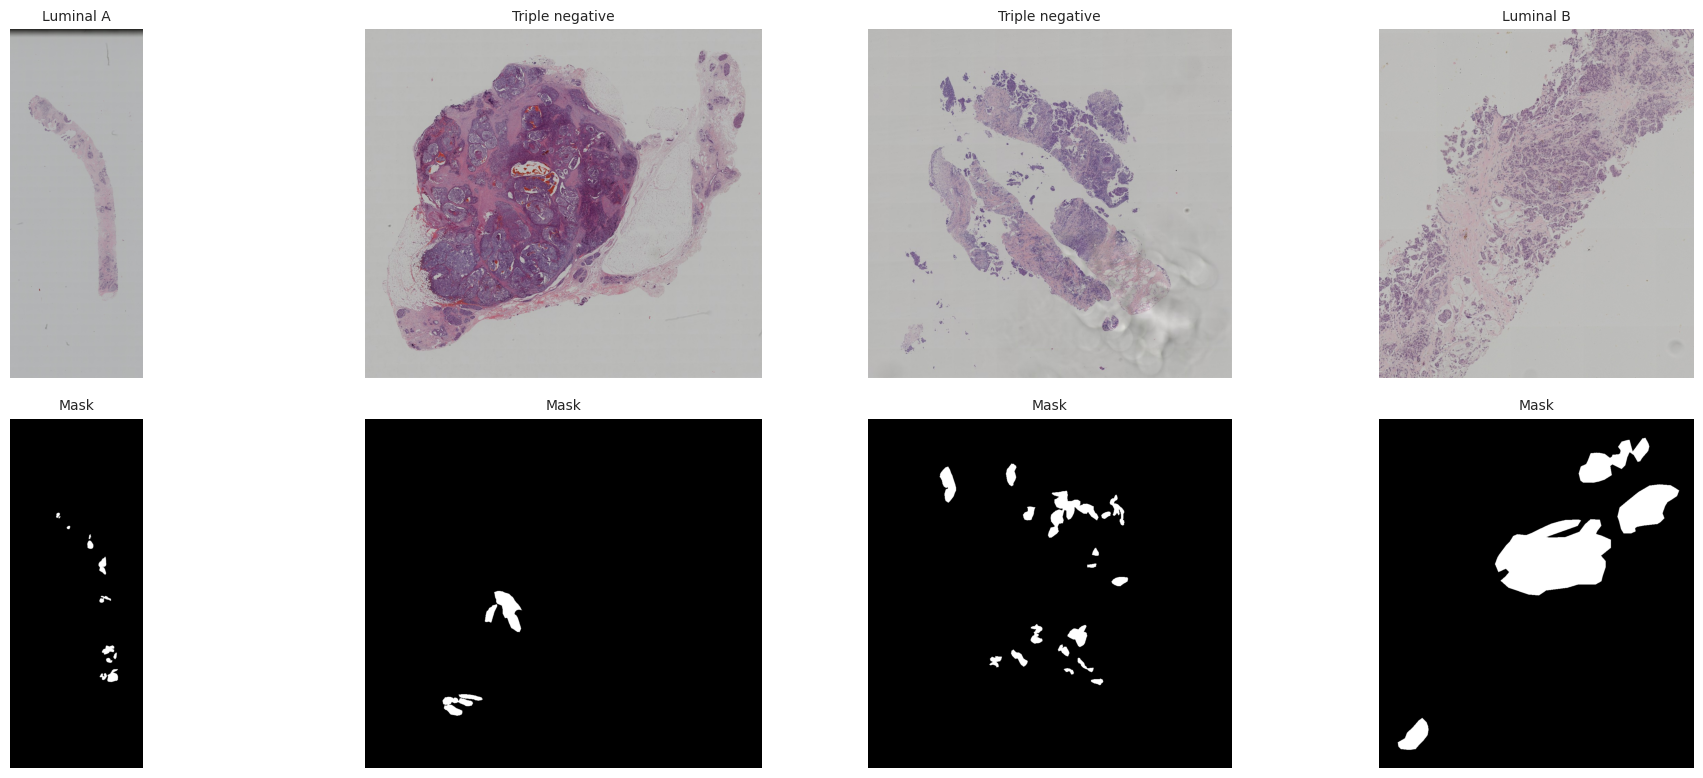

In [9]:
def visualize_samples(df, img_dir, mask_dir, n_samples=8, use_mask=True):
    """Visualize random samples with their masks"""
    if use_mask:
        fig, axes = plt.subplots(2, n_samples, figsize=(20, 8))
    else:
        fig, axes = plt.subplots(1, n_samples, figsize=(20, 4))
        axes = np.array([axes])  # Make it 2D for consistent indexing

    samples = df.sample(min(n_samples, len(df)))

    for idx, (_, row) in enumerate(samples.iterrows()):
        img_name = row['sample_index']
        label = row['label']

        # Load image
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)

        # Check if image was loaded successfully
        if img is None:
            print(f"Warning: Could not load image at {img_path}. Skipping.")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image
        axes[0, idx].imshow(img)
        axes[0, idx].set_title(f"{label}", fontsize=10)
        axes[0, idx].axis('off')

        # Load and display mask
        if use_mask:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = os.path.join(mask_dir, mask_name)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    axes[1, idx].imshow(mask, cmap='gray')
                    axes[1, idx].set_title(f"Mask", fontsize=10)
                    axes[1, idx].axis('off')
                else:
                    print(f"Warning: Could not load mask at {mask_path}")
                    axes[1, idx].axis('off')
            else:
                print(f"Warning: Mask not found at {mask_path}")
                axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizing sample images and masks...")
visualize_samples(train_labels, TRAIN_IMG_DIR, TRAIN_MASK_DIR, n_samples=4)

## **Data Preprocessing**

In [10]:
class TissueDataset(Dataset):
    """Custom Dataset for tissue images with optional mask support"""

    def __init__(self, df, img_dir, mask_dir, label_to_idx, transform=None, use_mask=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.label_to_idx = label_to_idx
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get image ID and label
        img_name = self.df.loc[idx, 'sample_index']
        label = self.df.loc[idx, 'label']
        label_idx = self.label_to_idx[label]

        # Load image
        img_path = os.path.join(self.img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Optionally apply mask
        if self.use_mask:
            # Convert img_xxxx.png to mask_xxxx.png
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = os.path.join(self.mask_dir, mask_name)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = mask / 255.0  # Normalize to [0, 1]
                mask = np.expand_dims(mask, axis=-1)  # Add channel dimension
                img = img * mask  # Apply mask
                img = img.astype(np.uint8)

        # Apply transforms
        if self.transform:
            img = self.transform(img)

        return img, label_idx

class TestTissueDataset(Dataset):
    """Custom Dataset for test images (no labels)"""

    def __init__(self, image_files, data_dir, transform=None, use_mask=False):
        self.image_files = image_files
        self.data_dir = data_dir
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]

        # Load image
        img_path = os.path.join(self.data_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # For test data, masks might have same filename in test_data folder
        if self.use_mask:
            # Try to find corresponding mask (if exists)
            mask_file = img_file  # Assuming same filename for mask
            mask_path = os.path.join(self.data_dir, mask_file)

            if os.path.exists(mask_path) and 'mask' in mask_file.lower():
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                # Locate the pixels of the diseased region
                ys, xs = np.where(mask > 0)

                # If the mask is not empty
                if len(xs) > 0 and len(ys) > 0:
                    x1, x2 = xs.min(), xs.max()
                    y1, y2 = ys.min(), ys.max()

                # Crop the original image
                img = img[y1:y2, x1:x2]

        if self.transform:
            img = self.transform(img)

        return img, img_file

In [11]:
#Image size for the model
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [12]:
#augmentation
# IMG_SIZE = 224

# train_transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),  # crop casuale
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),  # rotazioni ±20°
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.ToTensor()
# ])

# val_transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor()
# ])

In [13]:
# Split data into train and validation sets
train_df, val_df = train_test_split(
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels['label']
)

print(f"\nTrain size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")

print("\nTrain class distribution:")
print(train_df['label'].value_counts())
print("\nValidation class distribution:")
print(val_df['label'].value_counts())

# Create datasets
USE_MASK = True

train_dataset = TissueDataset(
    train_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=train_transform, use_mask=USE_MASK
)

val_dataset = TissueDataset(
    val_df, TRAIN_IMG_DIR, TRAIN_MASK_DIR, label_to_idx,
    transform=val_transform, use_mask=USE_MASK
)


Train size: 464
Validation size: 116

Train class distribution:
label
Luminal B          163
Luminal A          126
HER2(+)            120
Triple negative     55
Name: count, dtype: int64

Validation class distribution:
label
Luminal B          41
Luminal A          31
HER2(+)            30
Triple negative    14
Name: count, dtype: int64


In [14]:
# Define the batch size
BATCH_SIZE = 32

In [15]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [16]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [17]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break  # Stop after getting one batch

Features batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


In [18]:
input_shape = (xb.shape[1], xb.shape[2], xb.shape[3])
num_classes = len(label_to_idx)

## **Network Parameters**

In [20]:
# Number of training epochs
LEARNING_RATE = 1e-3
EPOCHS = 100
PATIENCE = 10

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 0              # L2 penalty

# Set up loss function
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Epochs: 100
Batch Size: 32
Learning Rate: 0.001
Dropout Rate: 0.2
L1 Penalty: 0
L2 Penalty: 0


## **Build the Model**

In [21]:
import torchvision.models as models
import torch.nn as nn

class ResNetClassifier(nn.Module):
    """
    ResNet18-based classifier using transfer learning.
    The backbone is pretrained on ImageNet.
    """

    def __init__(self, num_classes=4, dropout_rate=0.4, freeze_backbone=True):
        super().__init__()

        # Load pretrained ResNet18
        self.backbone = models.resnet18(pretrained=True)

        # Optionally freeze backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Replace classification head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

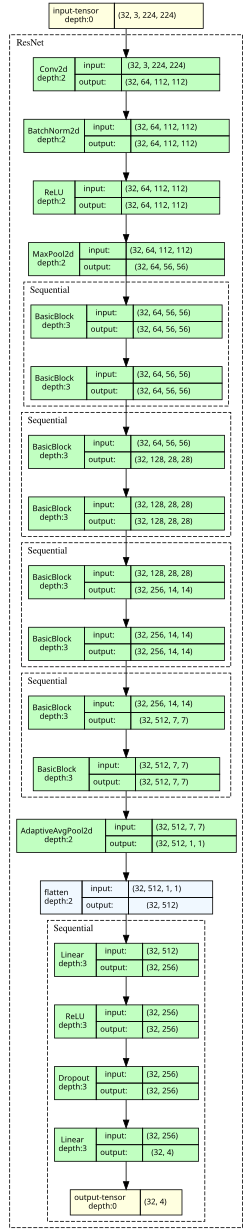

In [22]:
resnet_model = ResNetClassifier(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    freeze_backbone=True
).to(device)

summary(resnet_model, input_size=input_shape)

model_graph = draw_graph(
    resnet_model,
    input_size=(BATCH_SIZE,) + input_shape,
    expand_nested=True
)
model_graph.visual_graph

In [23]:
experiment_name = "resnet18_transfer"
writer = SummaryWriter("./" + logs_dir + "/" + experiment_name)

x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(resnet_model, x)

optimizer = torch.optim.Adam(
    resnet_model.backbone.fc.parameters(),
    lr=LEARNING_RATE,
    weight_decay=L2_LAMBDA
)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))


## **Training functions**

In [24]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [25]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [26]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [27]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [28]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

##**Training**

In [24]:
# %%time
# # Train model and track training history
# resnet_model, resnet_history = fit(
#     model=resnet_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=EPOCHS,
#     criterion=criterion,
#     optimizer=optimizer,
#     scaler=scaler,
#     device=device,
#     writer=writer,
#     verbose=1,
#     experiment_name="resnet18",
#     patience=PATIENCE
# )

# # Update best model if current performance is superior
# if resnet_history['val_f1'][-1] > best_performance:
#     best_model = resnet_model
#     best_performance = resnet_history['val_f1'][-1]

# # Calculate and print the final validation F1 score
# final_val_f1 = round(max(resnet_history['val_f1']) * 100, 2)
# print(f'Final validation F1 score: {final_val_f1}%')

In [25]:
# # @title Plot History
# # Create a figure with two side-by-side subplots
# fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# # Plot of training and validation loss on the first axis
# ax1.plot(resnet_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
# ax1.plot(resnet_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
# ax1.set_title('Categorical Crossentropy')
# ax1.legend()
# ax1.grid(alpha=0.3)

# # Plot of training and validation F1 score on the second axis
# ax2.plot(resnet_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
# ax2.plot(resnet_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
# ax2.set_title('F1 Score')
# ax2.legend()
# ax2.grid(alpha=0.3)

# # Adjust the layout and display the plot
# plt.tight_layout()
# plt.subplots_adjust(right=0.85)
# plt.show()

##**Fine Tuning**

In [37]:
# ft_model = ResNetClassifier(...) already defined above
ft_model = ResNetClassifier(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    freeze_backbone=False
).to(device)

# Congela tutti i parametri
for param in ft_model.parameters():
    param.requires_grad = False

# Sblocca la testa
for param in ft_model.backbone.fc.parameters():
    param.requires_grad = True

# Backbone blocks
backbone_layers = [
    ft_model.backbone.layer1,
    ft_model.backbone.layer2,
    ft_model.backbone.layer3,
    ft_model.backbone.layer4
]

# Quanti ultimi layer vuoi sbloccare
N_LAYERS_TO_UNFREEZE = 2

# Sblocca gli ultimi N layer
for layer in backbone_layers[-N_LAYERS_TO_UNFREEZE:]:
    for param in layer.parameters():
        param.requires_grad = True

# Check which parameters are trainable
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Trainable parameters: 10,625,796 / 11,308,868


In [38]:
# Create data loaders with different settings for each phase
train_ft_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_ft_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [39]:
# Setup Training (Lower learning rate for Fine-Tuning)
experiment_name = "fine_tuning_resnet"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4) # 10x smaller LR
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [41]:
%%time
# Fine-tune the model
ft_model, ft_history = fit(
    model=ft_model,
    train_loader=train_ft_loader,
    val_loader=val_ft_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=5,
    experiment_name=experiment_name,
    patience=PATIENCE
)

final_val_acc = round(max(ft_history['val_f1']) * 100, 2)
print(f'Final validation accuracy: {final_val_acc}%')

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.2543, F1 Score=0.3458 | Val: Loss=1.3219, F1 Score=0.2411
Epoch   5/100 | Train: Loss=0.1577, F1 Score=1.0000 | Val: Loss=1.6074, F1 Score=0.3377
Epoch  10/100 | Train: Loss=0.0198, F1 Score=1.0000 | Val: Loss=2.0849, F1 Score=0.2954
Epoch  15/100 | Train: Loss=0.0289, F1 Score=0.9978 | Val: Loss=2.2649, F1 Score=0.3368
Epoch  20/100 | Train: Loss=0.0039, F1 Score=1.0000 | Val: Loss=2.3821, F1 Score=0.2995
Early stopping triggered after 24 epochs.
Best model restored from epoch 14 with val_f1 0.3800
Final validation accuracy: 38.0%
CPU times: user 52.2 s, sys: 6.46 s, total: 58.7 s
Wall time: 27min 40s


## **Inference**

In [29]:
# Get list of test images
test_files = sorted([f for f in os.listdir(TEST_DATA_DIR) if f.endswith('.png') and 'img_' in f])
print(f"Found {len(test_files)} test images")

# Display a few test file names
print("\nFirst 5 test files:")
for i in range(min(5, len(test_files))):
    print(f"  {test_files[i]}")

# Create test dataset
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = TestTissueDataset(
    test_files,
    TEST_DATA_DIR,
    transform=test_transform,
    use_mask=USE_MASK
)

# Create test data loader
test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"\nTest loader created with {len(test_loader)} batches")

Found 477 test images

First 5 test files:
  img_0000.png
  img_0001.png
  img_0002.png
  img_0003.png
  img_0004.png

Test loader created with 15 batches


In [30]:
def predict_test_set(model, test_loader, device, idx_to_label):
    """
    Generate predictions for the entire test set.

    Args:
        model (nn.Module): Trained neural network model
        test_loader (DataLoader): DataLoader containing test images
        device (torch.device): Computing device (CPU/GPU)
        idx_to_label (dict): Mapping from class indices to label names

    Returns:
        tuple: (image_filenames, predicted_labels)
    """
    model.eval()

    all_predictions = []
    all_filenames = []

    print("Generating predictions...")

    with torch.no_grad():
        for batch_idx, (images, filenames) in enumerate(test_loader):
            # Move images to device
            images = images.to(device)

            # Forward pass with mixed precision
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(images)

            # Get predicted class indices
            predictions = logits.argmax(dim=1).cpu().numpy()

            # Store results
            all_predictions.extend(predictions)
            all_filenames.extend(filenames)

            # Progress update
            if (batch_idx + 1) % 10 == 0:
                print(f"Processed {(batch_idx + 1) * len(images)}/{len(test_dataset)} images")

    # Convert class indices to label names
    predicted_labels = [idx_to_label[idx] for idx in all_predictions]

    print(f"\nPrediction complete! Generated {len(predicted_labels)} predictions")

    return all_filenames, predicted_labels

def create_submission_file(filenames, labels, model_name='model'):
    """
    Create a submission CSV file in the required format with unique timestamp.

    Args:
        filenames (list): List of image filenames
        labels (list): List of predicted labels
        model_name (str): Name of the model used for predictions

    Returns:
        tuple: (submission_df, output_path)
    """
    from datetime import datetime

    # Generate unique filename with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_path = f'submission_{model_name}_{timestamp}.csv'

    # Create dataframe
    submission_df = pd.DataFrame({
        'sample_index': filenames,
        'label': labels
    })

    # Save to CSV
    submission_df.to_csv(output_path, index=False)

    print(f"\n{'='*70}")
    print(f"SUBMISSION FILE CREATED")
    print(f"{'='*70}")
    print(f"File saved to: {output_path}")
    print(f"Model: {model_name}")
    print(f"Timestamp: {timestamp}")
    print(f"Total predictions: {len(submission_df)}")

    # Display class distribution in predictions
    print(f"\nPredicted class distribution:")
    print(submission_df['label'].value_counts().sort_index())

    # Display first few rows
    print(f"\nFirst 10 rows of submission file:")
    print(submission_df.head(10))

    return submission_df, output_path

In [31]:
# Load the best model (fine-tuned model in this case)
print("\n" + "="*70)
print("LOADING BEST MODEL FOR INFERENCE")
print("="*70)

# Choose which model to use for final predictions
inference_model = ResNetClassifier(num_classes, DROPOUT_RATE, freeze_backbone=False).to(device)
inference_model.load_state_dict(torch.load("models/fine_tuning_resnet_model.pt"))

# Generate predictions on test set
test_filenames, test_predictions = predict_test_set(
    model=inference_model,
    test_loader=test_loader,
    device=device,
    idx_to_label=idx_to_label
)

# Create submission CSV file
submission_df, submission_path = create_submission_file(
    filenames=test_filenames,
    labels=test_predictions,
    model_name='resnet_ft'
)

# Verify the submission file format
print("\n" + "="*70)
print("SUBMISSION FILE VERIFICATION")
print("="*70)

# Check if file exists
if os.path.exists(submission_path):
    print("Submission file exists")

    # Verify file format
    verify_df = pd.read_csv(submission_path)

    # Check column names
    if list(verify_df.columns) == ['sample_index', 'label']:
        print("Column names are correct")
    else:
        print("WARNING: Column names are incorrect!")
        print(f"Expected: ['sample_index', 'label']")
        print(f"Found: {list(verify_df.columns)}")

    # Check number of predictions
    expected_count = len(test_files)
    actual_count = len(verify_df)
    if actual_count == expected_count:
        print(f"Number of predictions is correct ({actual_count})")
    else:
        print(f"WARNING: Number of predictions mismatch!")
        print(f"Expected: {expected_count}")
        print(f"Found: {actual_count}")

    # Check for valid labels
    valid_labels = set(label_to_idx.keys())
    predicted_labels_set = set(verify_df['label'].unique())
    if predicted_labels_set.issubset(valid_labels):
        print("All predicted labels are valid")
    else:
        invalid_labels = predicted_labels_set - valid_labels
        print(f"WARNING: Found invalid labels: {invalid_labels}")

    # Check for missing values
    if verify_df.isnull().sum().sum() == 0:
        print("No missing values")
    else:
        print("WARNING: Found missing values!")
        print(verify_df.isnull().sum())

    print("\n" + "="*70)
    print("READY FOR SUBMISSION!")
    print("="*70)

else:
    print("ERROR: Submission file was not created!")


LOADING BEST MODEL FOR INFERENCE
Generating predictions...
  Processed 320/477 images

Prediction complete! Generated 477 predictions

SUBMISSION FILE CREATED
File saved to: submission_resnet_ft_20251215_125754.csv
Model: resnet_ft
Timestamp: 20251215_125754
Total predictions: 477

Predicted class distribution:
label
HER2(+)              1
Luminal A            1
Luminal B          410
Triple negative     65
Name: count, dtype: int64

First 10 rows of submission file:
   sample_index            label
0  img_0000.png        Luminal B
1  img_0001.png        Luminal B
2  img_0002.png        Luminal B
3  img_0003.png        Luminal B
4  img_0004.png        Luminal B
5  img_0005.png        Luminal B
6  img_0006.png        Luminal B
7  img_0007.png        Luminal B
8  img_0008.png        Luminal B
9  img_0009.png  Triple negative

SUBMISSION FILE VERIFICATION
Submission file exists
Column names are correct
Number of predictions is correct (477)
All predicted labels are valid
No missing value


Visualizing random test predictions...


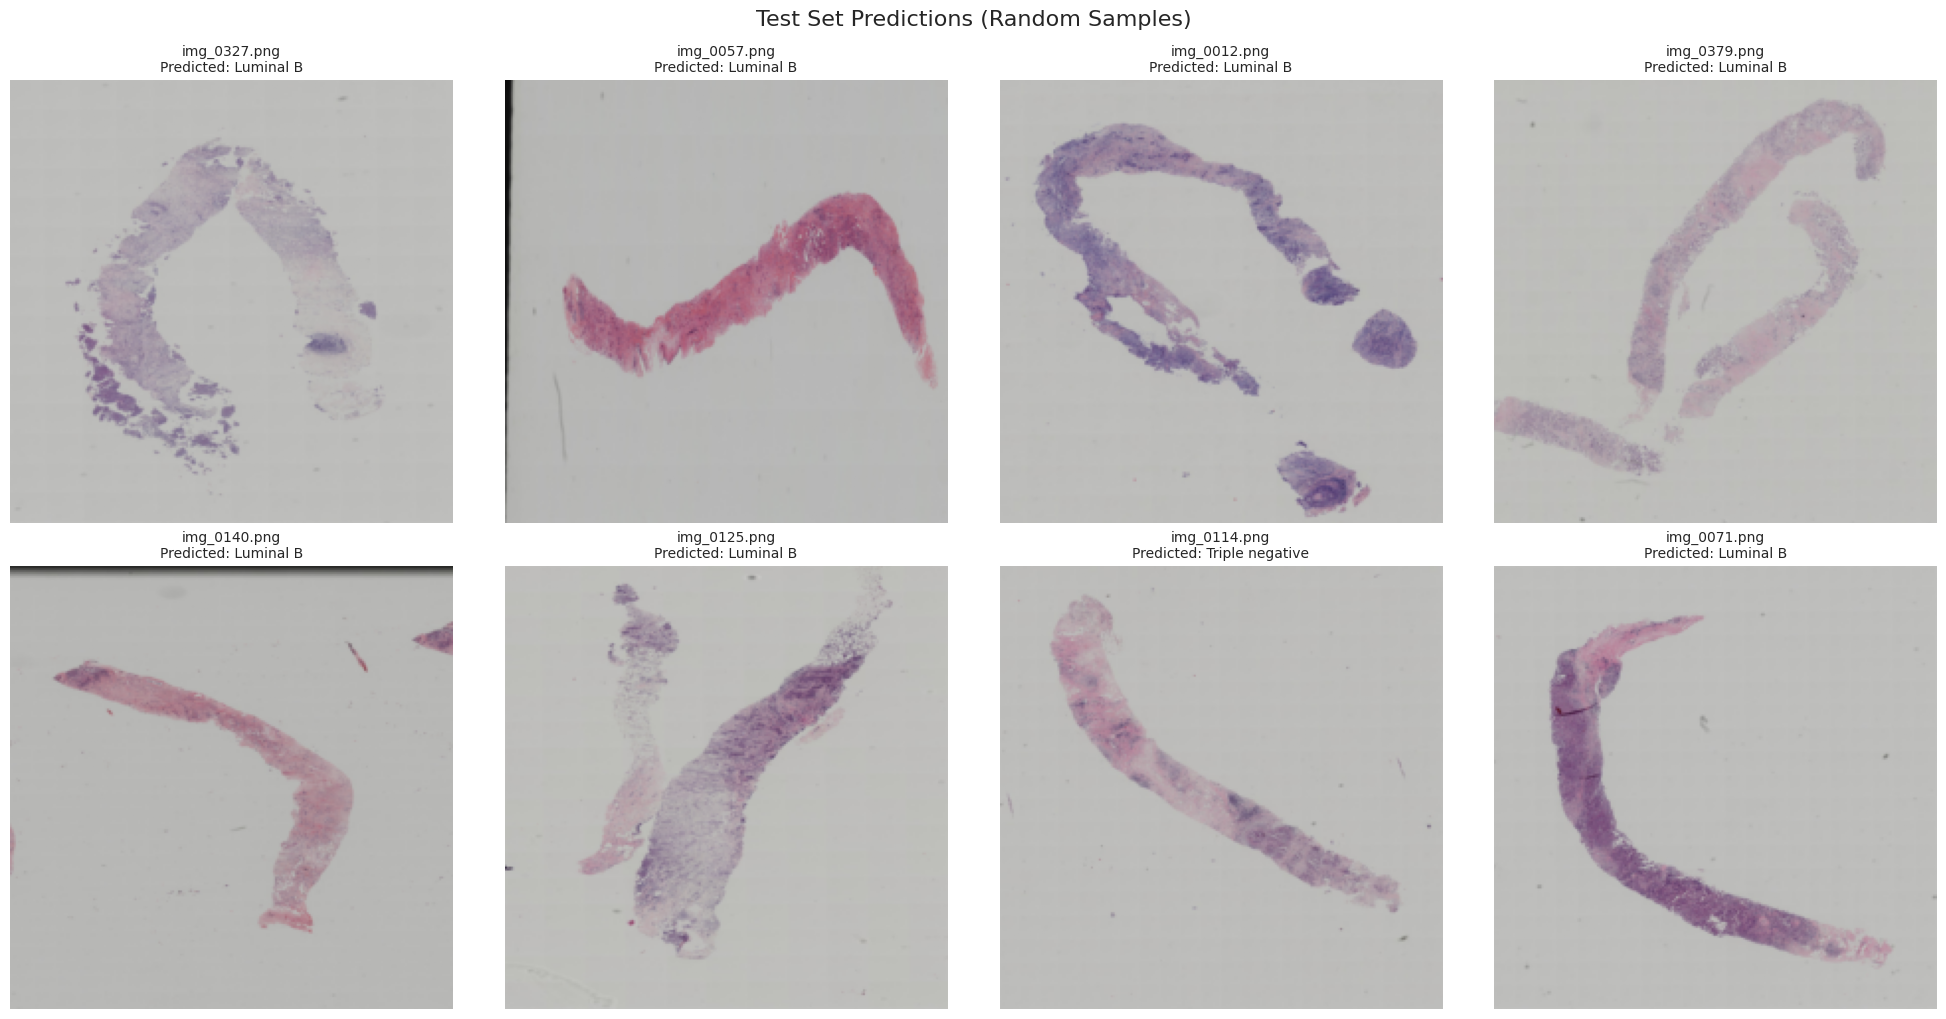

In [32]:
# Optional: Visualize some test predictions
def visualize_test_predictions(test_dataset, predictions, idx_to_label, n_samples=8):
    """
    Visualize random test images with their predicted labels.

    Args:
        test_dataset (Dataset): Test dataset containing images
        predictions (list): List of predicted class indices
        idx_to_label (dict): Mapping from indices to label names
        n_samples (int): Number of samples to display
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    # Select random samples
    sample_indices = random.sample(range(len(test_dataset)), min(n_samples, len(test_dataset)))

    for i, idx in enumerate(sample_indices):
        # Get image and filename
        img_tensor, filename = test_dataset[idx]

        # Denormalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = img_tensor * std + mean
        img_display = torch.clamp(img_display, 0, 1)
        img_display = img_display.permute(1, 2, 0).numpy()

        # Get prediction
        pred_label = test_predictions[test_filenames.index(filename)]

        # Display
        axes[i].imshow(img_display)
        axes[i].set_title(f"{filename}\nPredicted: {pred_label}", fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.suptitle('Test Set Predictions (Random Samples)', fontsize=16, y=1.02)
    plt.show()

# Visualize some predictions
print("\nVisualizing random test predictions...")
visualize_test_predictions(test_dataset, test_filenames, idx_to_label, n_samples=8)